<a href="https://colab.research.google.com/github/manishkshtriya333-arch/Deep-Learning-Assignment2/blob/main/dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.8MB/s]


Train: 60000 | Test: 10000


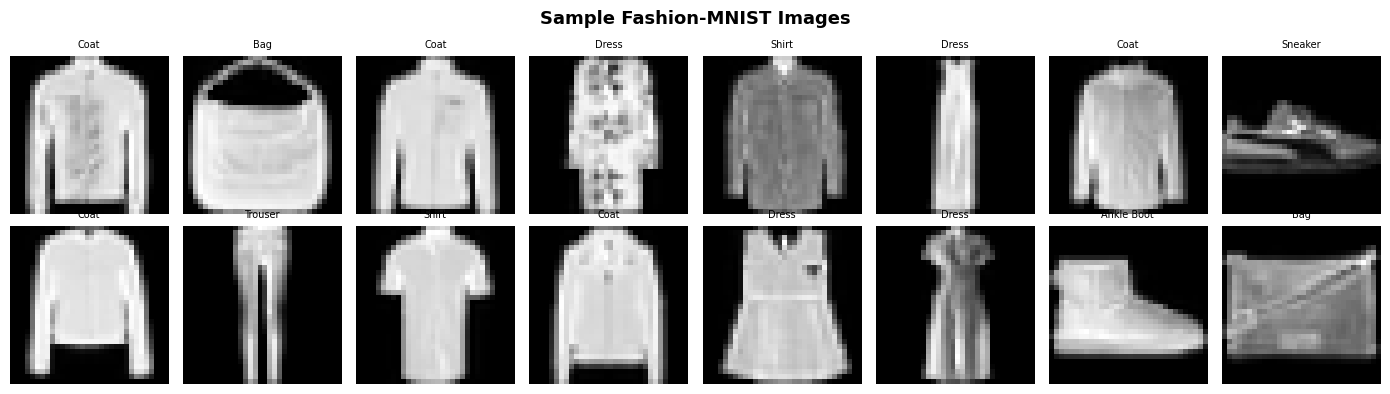

CustomCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Total Parameters: 544,714


In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ── Device ───────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# ── Load Fashion-MNIST ────────────────────────────────────────
transform_train = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
transform_test = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform_train)
test_dataset  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

classes = ['T-shirt','Trouser','Pullover','Dress','Coat',
           'Sandal','Shirt','Sneaker','Bag','Ankle Boot']
print(f'Train: {len(train_dataset)} | Test: {len(test_dataset)}')

# ── Visualise Samples ─────────────────────────────────────────
dataiter = iter(train_loader)
images, labels = next(dataiter)
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img = images[i].squeeze().numpy()
    img = (img * 0.5) + 0.5
    ax.imshow(img, cmap='gray')
    ax.set_title(classes[labels[i].item()], fontsize=7)
    ax.axis('off')
plt.suptitle('Sample Fashion-MNIST Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Custom CNN Model ──────────────────────────────────────────
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        # Conv Block 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)      # 32x32 -> 16x16
        )
        # Conv Block 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)      # 16x16 -> 8x8
        )
        # Fully Connected
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.fc(x)
        return x

model_cnn = CustomCNN().to(device)
print(model_cnn)
print(f'Total Parameters: {sum(p.numel() for p in model_cnn.parameters()):,}')

# ── Train Custom CNN ──────────────────────────────────────────
criterion     = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=0.001)

NUM_EPOCHS = 10
cnn_train_loss, cnn_train_acc, cnn_val_acc = [], [], []

for epoch in range(NUM_EPOCHS):
    model_cnn.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_cnn.zero_grad()
        outputs = model_cnn(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer_cnn.step()
        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc  = 100. * correct / total

    model_cnn.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_cnn(images)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total   += labels.size(0)
    val_acc = 100. * val_correct / val_total

    cnn_train_loss.append(train_loss)
    cnn_train_acc.append(train_acc)
    cnn_val_acc.append(val_acc)
    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] Loss: {train_loss:.4f} | Train: {train_acc:.2f}% | Val: {val_acc:.2f}%')

print(f'\nFinal CNN Test Accuracy: {cnn_val_acc[-1]:.2f}%')

# ── CNN Training Plots ────────────────────────────────────────
epochs_range = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_range, cnn_train_loss, 'b-o', linewidth=2, label='Training Loss')
axes[0].set_title('Custom CNN — Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, cnn_train_acc, 'b-o', linewidth=2, label='Train Accuracy')
axes[1].plot(epochs_range, cnn_val_acc,   'g-^', linewidth=2, label='Val Accuracy')
axes[1].set_title('Custom CNN — Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── Confusion Matrix ──────────────────────────────────────────
model_cnn.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_cnn(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix — Custom CNN (Fashion-MNIST)', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()
print(classification_report(all_labels, all_preds, target_names=classes))

# ── ResNet18 Transfer Learning ────────────────────────────────
model_resnet = models.resnet18(pretrained=True)
model_resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

for param in model_resnet.parameters():
    param.requires_grad = False

model_resnet.fc = nn.Linear(model_resnet.fc.in_features, 10)
for param in model_resnet.fc.parameters():
    param.requires_grad = True
for param in model_resnet.conv1.parameters():
    param.requires_grad = True

model_resnet = model_resnet.to(device)
print(f'Trainable Params: {sum(p.numel() for p in model_resnet.parameters() if p.requires_grad):,}')

# ── Train ResNet18 ────────────────────────────────────────────
optimizer_resnet = optim.Adam(
    filter(lambda p: p.requires_grad, model_resnet.parameters()), lr=0.001)

RESNET_EPOCHS = 5
resnet_train_loss, resnet_val_acc = [], []

for epoch in range(RESNET_EPOCHS):
    model_resnet.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_resnet.zero_grad()
        outputs = model_resnet(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer_resnet.step()
        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    train_loss = running_loss / len(train_loader)

    model_resnet.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_resnet(images)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total   += labels.size(0)
    val_acc = 100. * val_correct / val_total

    resnet_train_loss.append(train_loss)
    resnet_val_acc.append(val_acc)
    print(f'Epoch [{epoch+1}/{RESNET_EPOCHS}] Loss: {train_loss:.4f} | Val: {val_acc:.2f}%')

print(f'\nFinal ResNet18 Test Accuracy: {resnet_val_acc[-1]:.2f}%')

# ── CNN vs ResNet18 Bar Chart ─────────────────────────────────
plt.figure(figsize=(6, 4))
bars = plt.bar(['Custom CNN', 'ResNet18'],
               [cnn_val_acc[-1], resnet_val_acc[-1]],
               color=['#1F4E79', '#2E75B6'], width=0.4, edgecolor='white')
plt.ylim([55, 100])
plt.ylabel('Test Accuracy (%)')
plt.title('CNN vs ResNet18 — Fashion-MNIST', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{bar.get_height():.2f}%', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()


# ============================================================
#  PART B — SENTIMENT CLASSIFICATION (IMDB)
#  RNN vs LSTM vs GRU
# ============================================================

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

print(f'TensorFlow: {tf.__version__}')

# ── Load IMDB ─────────────────────────────────────────────────
VOCAB_SIZE   = 10000
MAX_LEN      = 200
EMBED_DIM    = 128
HIDDEN_UNITS = 128
BATCH_SIZE   = 32
EPOCHS       = 5

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)
X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test,  maxlen=MAX_LEN, padding='post', truncating='post')
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

# ── Model Builder ─────────────────────────────────────────────
def build_model(model_type):
    model = Sequential(name=model_type)
    model.add(Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN))
    if model_type == 'RNN':
        model.add(SimpleRNN(HIDDEN_UNITS))
    elif model_type == 'LSTM':
        model.add(LSTM(HIDDEN_UNITS))
    elif model_type == 'GRU':
        model.add(GRU(HIDDEN_UNITS))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# ── Train Simple RNN ──────────────────────────────────────────
print('\n--- Training Simple RNN ---')
model_rnn = build_model('RNN')
model_rnn.summary()
history_rnn = model_rnn.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                             validation_data=(X_test, y_test), callbacks=[early_stop], verbose=1)
rnn_loss, rnn_acc = model_rnn.evaluate(X_test, y_test, verbose=0)
print(f'Simple RNN — Accuracy: {rnn_acc*100:.2f}% | Loss: {rnn_loss:.4f}')

# ── Train LSTM ────────────────────────────────────────────────
print('\n--- Training LSTM ---')
model_lstm = build_model('LSTM')
model_lstm.summary()
history_lstm = model_lstm.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                               validation_data=(X_test, y_test), callbacks=[early_stop], verbose=1)
lstm_loss, lstm_acc = model_lstm.evaluate(X_test, y_test, verbose=0)
print(f'LSTM — Accuracy: {lstm_acc*100:.2f}% | Loss: {lstm_loss:.4f}')

# ── Train GRU ─────────────────────────────────────────────────
print('\n--- Training GRU ---')
model_gru = build_model('GRU')
model_gru.summary()
history_gru = model_gru.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                             validation_data=(X_test, y_test), callbacks=[early_stop], verbose=1)
gru_loss, gru_acc = model_gru.evaluate(X_test, y_test, verbose=0)
print(f'GRU — Accuracy: {gru_acc*100:.2f}% | Loss: {gru_loss:.4f}')

# ── Validation Plots ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_rnn.history['val_accuracy'],  'r-o', label='Simple RNN', linewidth=2)
axes[0].plot(history_lstm.history['val_accuracy'], 'g-s', label='LSTM',       linewidth=2)
axes[0].plot(history_gru.history['val_accuracy'],  'b-^', label='GRU',        linewidth=2)
axes[0].set_title('Validation Accuracy — RNN Models', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_rnn.history['val_loss'],  'r-o', label='Simple RNN', linewidth=2)
axes[1].plot(history_lstm.history['val_loss'], 'g-s', label='LSTM',       linewidth=2)
axes[1].plot(history_gru.history['val_loss'],  'b-^', label='GRU',        linewidth=2)
axes[1].set_title('Validation Loss — RNN Models', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


# ============================================================
#  PART C — IMAGE GENERATION (Fashion-MNIST)
#  Generative Adversarial Network (GAN)
# ============================================================

from tensorflow.keras.layers import LeakyReLU, Dropout, Reshape, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# ── Load Fashion-MNIST for GAN ────────────────────────────────
(X_gan, _), (_, _) = tf.keras.datasets.fashion_mnist.load_data()
X_gan = X_gan.astype('float32')
X_gan = (X_gan - 127.5) / 127.5        # Normalise to [-1, 1]
X_gan = X_gan.reshape(-1, 784)
print(f'GAN Training Data Shape: {X_gan.shape}')

NOISE_DIM  = 100
GAN_EPOCHS = 30
GAN_BATCH  = 128

# ── Generator ────────────────────────────────────────────────
def build_generator():
    model = Sequential(name='Generator')
    model.add(Dense(256, input_dim=NOISE_DIM))
    model.add(LeakyReLU(0.2))
    model.add(Dense(512))
    model.add(LeakyReLU(0.2))
    model.add(Dense(784, activation='tanh'))
    return model

# ── Discriminator ────────────────────────────────────────────
def build_discriminator():
    model = Sequential(name='Discriminator')
    model.add(Dense(512, input_dim=784))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.3))
    model.add(Dense(256))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(0.0002, 0.5),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

# ── GAN (Combined) ───────────────────────────────────────────
generator     = build_generator()
discriminator = build_discriminator()
discriminator.trainable = False

gan_input  = tf.keras.Input(shape=(NOISE_DIM,))
gan_output = discriminator(generator(gan_input))
gan_model  = Model(gan_input, gan_output, name='GAN')
gan_model.compile(optimizer=Adam(0.0002, 0.5), loss='binary_crossentropy')

generator.summary()
discriminator.summary()

# ── Training Loop ─────────────────────────────────────────────
d_losses, g_losses = [], []

def show_generated_images(epoch, generator, examples=15):
    noise = np.random.normal(0, 1, (examples, NOISE_DIM))
    gen_imgs = generator.predict(noise, verbose=0)
    gen_imgs = (gen_imgs + 1) / 2.0     # Rescale to [0,1]
    fig, axes = plt.subplots(3, 5, figsize=(10, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(gen_imgs[i].reshape(28, 28), cmap='gray')
        ax.axis('off')
    plt.suptitle(f'Generated Images — Epoch {epoch}', fontweight='bold')
    plt.tight_layout(); plt.show()

for epoch in range(GAN_EPOCHS):
    # ── Train Discriminator ───────────────────────────────────
    idx        = np.random.randint(0, X_gan.shape[0], GAN_BATCH)
    real_imgs  = X_gan[idx]
    noise      = np.random.normal(0, 1, (GAN_BATCH, NOISE_DIM))
    fake_imgs  = generator.predict(noise, verbose=0)

    real_labels = np.ones((GAN_BATCH, 1))
    fake_labels = np.zeros((GAN_BATCH, 1))

    d_loss_real = discriminator.train_on_batch(real_imgs, real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_imgs, fake_labels)
    d_loss      = 0.5 * (d_loss_real[0] + d_loss_fake[0])
    d_acc       = 0.5 * (d_loss_real[1] + d_loss_fake[1])

    # ── Train Generator ───────────────────────────────────────
    noise  = np.random.normal(0, 1, (GAN_BATCH, NOISE_DIM))
    g_loss = gan_model.train_on_batch(noise, np.ones((GAN_BATCH, 1)))

    d_losses.append(d_loss)
    g_losses.append(g_loss)

    print(f'Epoch [{epoch+1}/{GAN_EPOCHS}] | D Loss: {d_loss:.4f} | D Acc: {d_acc*100:.1f}% | G Loss: {g_loss:.4f}')

    # Show images at epoch 1, 10, 20, 30
    if (epoch + 1) in [1, 10, 20, 30]:
        show_generated_images(epoch + 1, generator)

# ── GAN Loss Plot ─────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(range(1, GAN_EPOCHS+1), d_losses, 'r-', label='Discriminator Loss', linewidth=2)
plt.plot(range(1, GAN_EPOCHS+1), g_losses, 'b-', label='Generator Loss',     linewidth=2)
plt.title('GAN Training Loss over Epochs', fontweight='bold', fontsize=13)
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


# ============================================================
#  FINAL RESULTS SUMMARY
# ============================================================

print('='*52)
print('           FINAL RESULTS SUMMARY')
print('='*52)
print(f'  PART A — Fashion-MNIST Classification')
print(f'  Custom CNN   : {cnn_val_acc[-1]:.2f}%')
print(f'  ResNet18     : {resnet_val_acc[-1]:.2f}%')
print('-'*52)
print(f'  PART B — IMDB Sentiment Classification')
print(f'  Simple RNN   : {rnn_acc*100:.2f}%')
print(f'  LSTM         : {lstm_acc*100:.2f}%')
print(f'  GRU          : {gru_acc*100:.2f}%')
print('-'*52)
print(f'  PART C — GAN Image Generation')
print(f'  Final D Loss : {d_losses[-1]:.4f}')
print(f'  Final G Loss : {g_losses[-1]:.4f}')
print('='*52)

# ── Overall Bar Chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
model_names = ['Custom CNN', 'ResNet18', 'Simple RNN', 'LSTM', 'GRU']
accuracies  = [cnn_val_acc[-1], resnet_val_acc[-1],
               rnn_acc*100, lstm_acc*100, gru_acc*100]
colors = ['#1F4E79', '#2E75B6', '#C00000', '#C00000', '#C00000']
bars = ax.bar(model_names, accuracies, color=colors, width=0.5, edgecolor='white')
ax.set_ylim([55, 100])
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Overall Model Accuracy Comparison', fontweight='bold', fontsize=13)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Test Custom Sentiment ─────────────────────────────────────
word_index = imdb.get_word_index()

def predict_sentiment(review, model):
    words = review.lower().split()
    seq   = [word_index.get(w, 2) + 3 for w in words]
    seq   = pad_sequences([seq], maxlen=MAX_LEN, padding='post', truncating='post')
    pred  = model.predict(seq, verbose=0)[0][0]
    label = 'POSITIVE 😊' if pred > 0.5 else 'NEGATIVE 😞'
    print(f'Review   : "{review}"')
    print(f'Sentiment: {label} (score: {pred:.2f})\n')

predict_sentiment("This movie was absolutely fantastic and brilliant", model_gru)
predict_sentiment("The film was boring and a complete waste of time", model_gru)
predict_sentiment("An average movie with some good moments", model_gru)
